# Module 0: What Is Prediction?

**Workshop Track:** 100-Level | Introduction
**Prerequisites:** Python 3.10+, NEXUS API key

---

Welcome to the very beginning. Before we dive into credit risk models, API patterns, and production pipelines, we need to answer one question: **what does "prediction" actually mean?**

This module uses a simple housing dataset to build your intuition. You will see a scatter plot, train a model, and make your own predictions using an interactive slider. By the end, the concept of "learning from data" will feel concrete, not abstract.

## Learning Objectives

By the end of this notebook you will:

- Understand what prediction means in the context of machine learning
- See how historical data reveals patterns that a model can learn
- Train your first model using NEXUS and make real predictions
- Interact with a live model to predict housing prices for any square footage you choose

---

## How to use this workshop

Modules use three markers so you can move at your own pace:

- **New to a topic?** Short primers appear right before the harder sections. Read them when the topic is new to you; skip them when it is not.
- **Optional — go deeper.** Sections with this label are extensions. Nothing later depends on them.
- **Already comfortable with a topic?** Skip-ahead notes tell you where to rejoin.

If you are new to machine learning, read everything in order. If you are experienced, follow the skip-ahead notes and take the optional deep dives.

---

## The Big Idea

Imagine you are shopping for a house. You have seen dozens of listings and noticed a pattern: **bigger houses tend to cost more**. That pattern is in your head, built from experience.

Machine learning does the same thing, but with math. You give it historical data — hundreds of real home sales with their square footage and price — and it finds the pattern automatically. Once it has the pattern, it can predict the price of a house it has never seen before.

That is prediction in one sentence: **using past data to estimate unknown outcomes.**

In this module, we make that idea tangible. We will:
1. Look at real housing data
2. See the pattern in a scatter plot
3. Ask NEXUS to learn the pattern
4. Use the trained model to predict prices for any square footage we choose

---

In [ ]:
# ============================================================================
# Workshop bootstrap — run this first. Safe to re-run. Identical in every module.
#
# In Google Colab, add two secrets via the key icon in the left sidebar
# (toggle "Notebook access" on for each):
#   • FUNDAMENTAL_API_KEY            — your NEXUS API key (ak_...)
#   • CLOUDSMITH_FUNDAMENTAL_TOKEN   — token to install the Fundamental SDK
#
# Each Colab notebook runs in its own fresh VM, so the modules share state
# (model IDs, feature lists) through a small JSON file on your Google Drive.
# This cell asks to mount Drive — approve the popup. If you decline, later
# modules will ask you to paste the values printed by earlier ones instead.
# See README.md for details.
# ============================================================================
import os, sys, json, subprocess
from pathlib import Path

# TODO at go-live: switch REPO to "Fundamental-Technologies/introduction-to-nexus"
REPO = "jawhnycooke/nexus_onboarding_workshop"

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# --- Dataset -----------------------------------------------------------------
# In Colab we sparse-fetch ONLY the dataset folder; the notebook itself is
# loaded straight from GitHub by Colab, so nothing else is needed on disk.
if IN_COLAB:
    _data_repo = Path("/content/workshop_data")
    DATASET_DIR = _data_repo / "dataset"
    if not DATASET_DIR.is_dir():
        print("Fetching the workshop dataset…")
        subprocess.run(["git", "clone", "--quiet", "--depth", "1", "--filter=blob:none",
                        "--sparse", f"https://github.com/{REPO}.git", str(_data_repo)],
                       check=True)
        subprocess.run(["git", "-C", str(_data_repo), "sparse-checkout", "set", "dataset"],
                       check=True)
    WORKSHOP_ROOT = Path("/content")
else:
    # Locally the notebooks live in workshop_colab/ inside the cloned repo,
    # and the dataset sits at the repo root.
    _here = Path.cwd().resolve()
    _repo_root = next((p for p in [_here, *_here.parents]
                       if (p / "workshop_colab").is_dir() and (p / "dataset").is_dir()), None)
    if _repo_root is None:
        raise RuntimeError(
            "Could not locate the repository root. Launch Jupyter from inside the "
            "cloned repository so the dataset/ folder can be found."
        )
    DATASET_DIR = _repo_root / "dataset"
    WORKSHOP_ROOT = _repo_root / "workshop_colab"

os.chdir(WORKSHOP_ROOT)

# --- Cross-module state ------------------------------------------------------
# Model IDs and the selected feature list pass between modules through one JSON
# file. In Colab it lives on your Google Drive so it survives across notebooks.
_DRIVE_MOUNTED = False
if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        _state_dir = Path("/content/drive/MyDrive/nexus_workshop")
        _state_dir.mkdir(parents=True, exist_ok=True)
        STATE_FILE = _state_dir / "_workshop_state.json"
        _DRIVE_MOUNTED = True
    except Exception as _e:
        print(f"Google Drive not mounted ({_e}).")
        print("State will NOT persist between notebooks — later modules will ask "
              "you to paste the values printed by earlier ones.")
        STATE_FILE = Path("/content/_workshop_state.json")
else:
    STATE_FILE = WORKSHOP_ROOT / "_workshop_state.json"


def save_state(key, value):
    state = json.loads(STATE_FILE.read_text()) if STATE_FILE.exists() else {}
    state[key] = value
    STATE_FILE.write_text(json.dumps(state, indent=2))
    print(f"Saved '{key}' = {value!r}")
    if IN_COLAB and not _DRIVE_MOUNTED:
        print("  (Drive is not mounted — copy this value; the next module will ask for it.)")


def load_state(key, default=None):
    if STATE_FILE.exists():
        return json.loads(STATE_FILE.read_text()).get(key, default)
    return default


def require_state(key, produced_by):
    val = load_state(key)
    if val is None:
        print(f"'{key}' was not found in the workshop state file ({STATE_FILE}).")
        print(f"It is produced by {produced_by}. If you ran that module without "
              "mounting Drive, paste the value it printed.")
        val = input(f"Paste {key} (or press Enter to abort): ").strip().strip("'\"")
        if not val:
            raise RuntimeError(
                f"'{key}' unavailable. Run {produced_by} first (approving the Drive "
                "mount), or re-run this cell and paste the printed value. See README.md."
            )
        save_state(key, val)
    return val


def _get_secret(name, required=True):
    val = os.getenv(name)
    if not val and IN_COLAB:
        try:
            from google.colab import userdata
            val = userdata.get(name)
        except Exception:
            val = None
    if required and not val:
        raise RuntimeError(
            f"Missing secret '{name}'.\n"
            "  • In Colab: open the key icon (Secrets) in the left sidebar, add a "
            f"secret named '{name}', and turn on 'Notebook access'.\n"
            f"  • Locally: export {name} in your shell before launching Jupyter.\n"
            "See README.md for details."
        )
    return val


# --- SDK install (Colab only; locally the SDK is installed during setup).
# Colab already ships pandas, numpy, scikit-learn, matplotlib and xgboost,
# so the Fundamental SDK is the only package to install.
try:
    import fundamental  # noqa: F401
except ImportError:
    if not IN_COLAB:
        raise RuntimeError(
            "Fundamental SDK not found. Install it locally (see README.md) before running."
        )
    _token = _get_secret("CLOUDSMITH_FUNDAMENTAL_TOKEN")
    print("Installing the Fundamental SDK…")
    _index = f"https://dl.cloudsmith.io/{_token}/fundamental/fundamental-client/python/simple/"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "fundamental-client==0.10.0", "--extra-index-url", _index], check=True)

# --- Authentication ---
FUNDAMENTAL_API_KEY = _get_secret("FUNDAMENTAL_API_KEY")
os.environ["FUNDAMENTAL_API_KEY"] = FUNDAMENTAL_API_KEY

from fundamental import Fundamental, NEXUSClassifier, NEXUSRegressor, set_client
client = Fundamental()
set_client(client)

print(f"Workshop ready. Dataset: {DATASET_DIR}")
print(f"State file: {STATE_FILE}"
      + ("" if _DRIVE_MOUNTED or not IN_COLAB else "  (not persistent — Drive not mounted)"))
print(f"API key prefix: {FUNDAMENTAL_API_KEY[:8]}…")


## Setup

The cell above is the **workshop bootstrap**. Run it first in every module — it is safe to re-run. On Google Colab it clones the workshop repository, installs the Fundamental SDK, reads your `FUNDAMENTAL_API_KEY` from Colab Secrets, authenticates, and wires up the cross-module state file. Running locally, it locates the dataset and authenticates from your environment.

NEXUS is a cloud service, so it needs an API key that identifies your account. Once the bootstrap has run, you are authenticated for the rest of this notebook.

## Meet the Data

We have a dataset of **545 real home sales**. Each row records a home's characteristics — square footage, number of bedrooms, parking spaces — and the price it sold for.

For this module, we care about just two columns:

| Column | What it is |
|--------|-----------|
| `area` | The home's size in square feet |
| `price` | The sale price in Indian Rupees (₹) |

One simple question: **if you know a home's square footage, can you predict its price?**

In [2]:
import pandas as pd

df = pd.read_csv(DATASET_DIR / "home_price/housing.csv")

print(f"Dataset: {df.shape[0]} homes, {df.shape[1]} columns")
print(f"\nArea range:  {df['area'].min():,} — {df['area'].max():,} sq ft")
print(f"Price range: ₹{df['price'].min():,.0f} — ₹{df['price'].max():,.0f}")
print()
print("First 5 rows:")
df[["area", "price"]].head()

Dataset: 545 homes, 13 columns

Area range:  1,650 — 16,200 sq ft
Price range: ₹1,750,000 — ₹13,300,000

First 5 rows:


,area,price
0,7420,13300000
1,8960,12250000
2,9960,12250000
3,7500,12215000
4,7420,11410000


## Visualizing the Relationship

Before we build any model, let's just look at the data. A **scatter plot** puts each home as a dot: square footage on the horizontal axis, price on the vertical axis.

If there is a relationship between size and price, we should see a pattern in the dots.

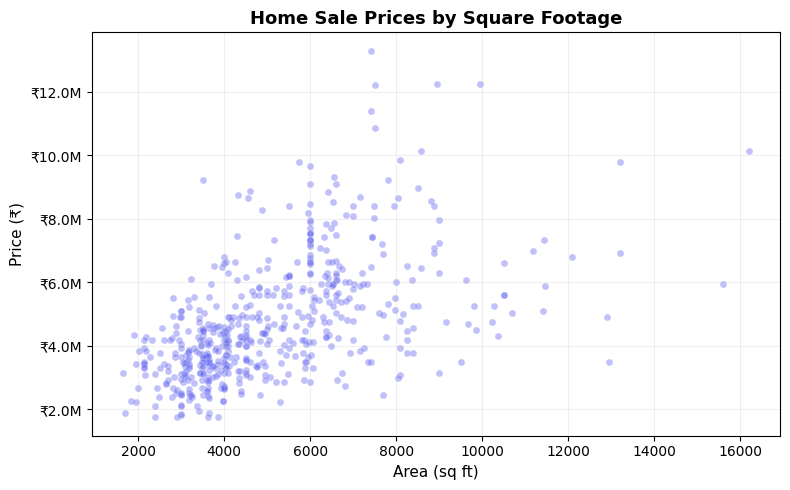

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df["area"], df["price"], alpha=0.4, color="#6366F1", s=25, edgecolors="white", linewidth=0.3)

ax.set_xlabel("Area (sq ft)", fontsize=11)
ax.set_ylabel("Price (₹)", fontsize=11)
ax.set_title("Home Sale Prices by Square Footage", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x/1e6:.1f}M"))
ax.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()

### The Pattern

You can see it: **bigger homes generally cost more.** The dots trend upward from left to right. There is scatter — a 5,000 sq ft home might sell for ₹3M or ₹7M depending on other factors — but the overall direction is clear.

This upward trend is the **pattern** in the data. A model's job is to find that pattern mathematically and use it to make predictions for homes we have never seen. The line it learns will not be perfectly smooth — expect some bumps and steps — but it still trends up.

---

## Training a Model

We are going to ask NEXUS to learn the relationship between square footage and price. In machine learning terms:

- **X** (features) = the square footage of each home
- **y** (target) = the price of each home
- **fit()** = "learn the pattern from this data"

Under the hood, NEXUS uploads your data to the cloud, trains a model on it, and returns a trained model you can use for predictions. All of that complexity is hidden behind two lines of code.

Training on 545 rows takes just a few seconds.

In [4]:
import numpy as np

# Prepare the data
X = df[["area"]]       # Feature: square footage (must be a DataFrame)
y = df["price"].values  # Target: sale price

# Train the model. Mode is set on the constructor, not on fit().
nexus = NEXUSRegressor(mode="speed")

print("Training...")
nexus.fit(X, y)

MODEL_ID = nexus.trained_model_id_
save_state("MODEL_ID", MODEL_ID)
print(f"\nTraining complete!")
print(f"Model ID: {MODEL_ID}")
print(f"Features used: {list(X.columns)}")

Training...


Saved 'MODEL_ID' to workshop state.

Training complete!
Model ID: adb64008-1f61-4970-a20c-afa8bd9685f1
Features used: ['area']


### What Just Happened?

NEXUS analyzed all 545 home sales and found the mathematical relationship between square footage and price. That relationship is now stored as a trained model in Fundamental's cloud, identified by the `Model ID` printed above.

Now comes the payoff: we can ask the model to **predict prices for any square footage**, including sizes that do not appear anywhere in our data.

---

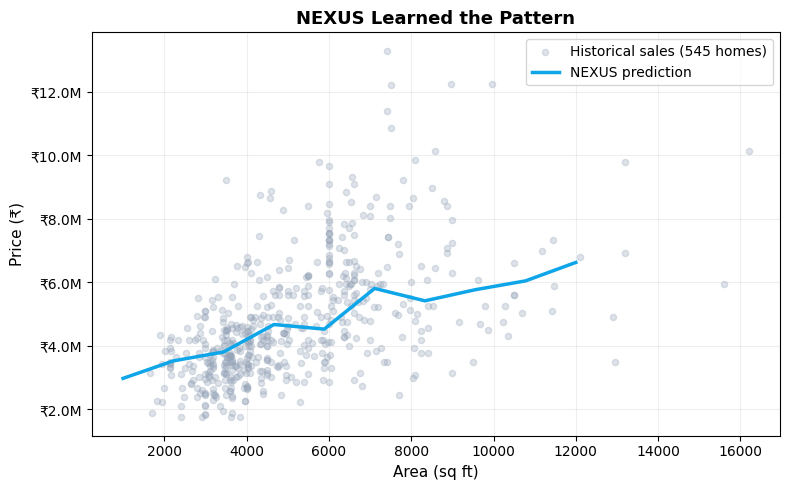

The blue line is what NEXUS learned. It captures the upward trend in the data.
Now you can pick ANY square footage and read off the predicted price.


In [5]:
# Predict across a range of square footages
area_range = np.linspace(1000, 12000, 10)
X_range = pd.DataFrame({"area": area_range})
predicted_prices = nexus.predict(X_range)

# Plot: real data + NEXUS prediction line
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df["area"], df["price"], alpha=0.3, color="#94A3B8", s=20, label="Historical sales (545 homes)")
ax.plot(area_range, predicted_prices, color="#0EA5E9", lw=2.5, label="NEXUS prediction")

ax.set_xlabel("Area (sq ft)", fontsize=11)
ax.set_ylabel("Price (₹)", fontsize=11)
ax.set_title("NEXUS Learned the Pattern", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x/1e6:.1f}M"))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()

print("The blue line is what NEXUS learned. It captures the upward trend in the data.")
print("Now you can pick ANY square footage and read off the predicted price.")

## Your Turn: Predict Any Home Price

Use the slider below to pick a square footage. The red dot shows where NEXUS predicts the price would land. Try values across the data range (about 1,650 to 16,200 sq ft) and watch how the prediction tracks the homes the model learned from. As you push past the largest homes, notice the prediction flattens out rather than climbing forever, because the model only learned the range it was shown.

**This is prediction in action:** you trained on historical data, and now you can estimate outcomes for sizes you never observed directly.

In [6]:
from ipywidgets import interact, IntSlider

def predict_and_plot(square_feet=5000):
    fig, ax = plt.subplots(figsize=(8, 5))

    # Historical data
    ax.scatter(df["area"], df["price"], alpha=0.3, color="#94A3B8", s=20, label="Historical sales")

    # NEXUS prediction line
    ax.plot(area_range, predicted_prices, color="#0EA5E9", lw=2.5, label="NEXUS prediction")

    # Student's prediction point
    student_input = pd.DataFrame({"area": [square_feet]})
    predicted_price = nexus.predict(student_input)[0]
    ax.scatter([square_feet], [predicted_price], color="#EF4444", s=150, zorder=5,
               edgecolors="white", linewidth=2,
               label=f"Your pick: {square_feet:,} sq ft → ₹{predicted_price:,.0f}")

    ax.set_xlabel("Area (sq ft)", fontsize=11)
    ax.set_ylabel("Price (₹)", fontsize=11)
    ax.set_title("Housing Price Prediction with NEXUS", fontsize=13, fontweight="bold")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x/1e6:.1f}M"))
    ax.legend(fontsize=10, loc="upper left")
    ax.grid(True, alpha=0.2)
    fig.tight_layout()
    plt.show()

interact(predict_and_plot,
         square_feet=IntSlider(min=1000, max=12000, step=10, value=5000,
                               description="Sq Ft:", style={"description_width": "50px"}))

interactive(children=(IntSlider(value=5000, description='Sq Ft:', max=12000, min=1000, step=10, style=SliderSt…

<function __main__.predict_and_plot(square_feet=5000)>

## From One Feature to Many

This module used a single feature — square footage — to predict price. In reality, a home's price depends on many factors: bedrooms, bathrooms, neighborhood, condition, and more.

The same idea scales. Instead of one column in X, you pass ten columns, or a hundred. The model finds patterns across all of them simultaneously. That is exactly what we do starting in Module 1, where we predict **loan default** using a borrower's age, employment history, number of prior lenders, and distance from the nearest branch.

The interface is identical: `fit(X, y)` and `predict(X)`. The only thing that changes is the shape of your data.

---

## Key Takeaways

1. **Prediction = using past data to estimate unknown outcomes.** We had 545 home sales. NEXUS found the price-vs-area pattern. Now we can predict prices for homes that were never in the dataset.

2. **The workflow is two steps: `fit()` then `predict()`.** `fit()` learns the pattern from your data. `predict()` applies that pattern to new inputs. This interface is the same across every module in this workshop.

3. **One feature is just the start.** Square footage alone leaves a lot of price variation unexplained. Real models use many features. Module 1 introduces a credit risk dataset with multiple columns and a binary outcome (default vs no default).

---

## What's Next: Module 1

In Module 1 we switch from housing prices to **credit risk** — predicting whether a borrower will default on a loan. You will:

- Use `NEXUSClassifier()` for binary prediction (yes/no) instead of continuous prices
- Work with four numeric features simultaneously
- Evaluate your model with ROC AUC, precision, recall, and a confusion matrix
- Save your trained model ID for use in every subsequent module

Your API key is already stored. Let's go.